# Introduction

Scentific Questions:
1) What, if anything, are the temporal and spatial trends in precipitation, temperature, and plant health across the midwestern United States in summer months, in recent history?
2) Are there any indicators of possible relationships between any apparent trends in precipitation, temperature, and plant health? 

The motivation for this research comes from my experiences working as a research technician for the Blesh Soil and Agroecosystems Lab at the University of Michigan from 2019 to 2020. Much of the lab’s work focused on understanding the use of cover cropping practices by Michigan farmers and analyzing the potential of cover crops to address concerns that farmers raised across a span of issues that they were facing. One of the major problems repeatedly cited by farmers was that, in their perception, changing precipitation and temperature patterns in recent growing seasons had resulted in decreased yields and entirely loss harvests.

As such, for this project I used precipitation, temperature, and vegetation data to attempt to analyze and visualize any type of relationship that may exist between changes in precipitation and temperature in the midwestern United States and trends in plant health in the same region, at the same time. I hypothesize that as trends in precipitation and temperature depart more from their previous patterns, plant life will struggle to adjust to these changes, causing larger declines in plant health indicators in areas of greater change. 

In [ ]:
## Open necessary packages

import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.colors as mcolors
import cartopy.crs as ccrs
import cartopy.feature as cfeature

from mpl_toolkits.axes_grid1.axes_divider import make_axes_locatable
from matplotlib import pyplot as plt
plt.rcParams['figure.figsize'] = (12, 6)

# Methods

The data for this research comes from the following datasets.

[FAPAR/LAI Data](https://www.ncei.noaa.gov/products/climate-data-records/leaf-area-index-and-fapar) This dataset contains daily measurements for, among other variables, two important plant health indicators: FAPAR (Fraction of Absorbed Photosynthetically Active Radiation) and LAI (Leaf Area Index). Both datasets come from information collected by the Advanced Very High Resolution Radiometer sensors from 1981–2013, on a .05° by .05° grid. FAPAR data indicate the percentage of available photosynthetically active radiaton that is actually absorbed by plants. LAI data represents the amount of one-sided green leaf area for each unit of ground surface area, from barren land (0) to total coverage (1) to multiple layers of canopies (>1). Both of these are considered important health indicators for plant life, quantifying overall abundance, plant metabolic health, and other signs of vegetation wellness. 

[Precipitation/Temperature Data](https://www.ncei.noaa.gov/access/metadata/landing-page/bin/iso?id=gov.noaa.ncdc:C00332) The precipitation and temperature information for this research comes from the NOAA Monthly U.S. Climate Gridded Dataset. This dataset contains monthly values for multiple variables across the continential United States from 1895 to the present. Precipitation is measured in total mm per month and temperature is measured as the monthly average of daily average temperatures, for each observed coordinate.

Spatially, I considered the area of ‘the midwest’ to be best approached for this research as a bounded range of longitude and latitude coordinates (49.5-36 N, 105.5-79 W). This range includes all of the area of all of the states considered to be the 'Midwest' by the United States Census. The dataset for precipitation and temperature only includes coordinates from this range that are part of the continuous United States of America, whereas the dataset for FAPAR and LAI also includes a limited number of data points from within Canada as well.

In terms of time, I chose to look at monthly data from the months of June, July, and August, from between 1982-2013. I chose to only look at summer months, as this is the peak of the agricultural season in this region. I chose to look at monthly data both as a consideration of memory and processing capacity, but also as a way to try to reduce noise from days where cloud coverage or other issues may have interfered with daily data capture. And I selected this series of years as the type of sensor used for collecting the FAPAR and LAI data was changed after this point. While the precipitation and temperature data were already available in monthly intervals, I had to average the daily FAPAR/LAI data as part of this work. 

For analysis, first I plan to visualize timeseries data for precipitation and temperature to see if any longer term shifts in overall averages are apparent across the entire midwestern region. Then, I plan to analyze and map the trends across the entire dataset for each individual variable across the entire region, to see if there is spatial variation in the overall trends for precipitation, temperature, FAPAR and LAI. Then, I plan to overlay maps of trends in precipitation and temperature with FAPAR and LAI, seperately, to visualize if areas of larger changes in either precipitation or temperature overlap with larger decreases in FAPAR or LAI.

In [2]:
## Summer Precipitation Dataset
## prcp = total millimeters of precipitation, per month

prcp_url = 'https://www.ncei.noaa.gov/thredds/dodsC/data-in-development/nclimgrid/nclimgrid_prcp.nc'
prcp_ds = xr.open_dataset(prcp_url)

## Only include the midwestern USA and only include times corresponding to LAI/FAPAR data.
time_range = slice("1982-06-01", "2013-08-31")
lat_range = slice(49.5, 36)
lon_range = slice(-105.5, -79)
prcp_subset_ds = prcp_ds.sel(time=time_range, lat=lat_range, lon=lon_range)

## Only looking at summer months, to emphasize change during peak agricultural season. 
## Each lon/lat coordinate already has is data as monthly total millimeters of precipation. 
summer_months = [6, 7, 8] 
prcp_summer_ds = prcp_subset_ds.where(prcp_subset_ds['time.month'].isin(summer_months), drop=True)

print(prcp_summer_ds)

<xarray.Dataset> Size: 78MB
Dimensions:  (time: 96, lat: 321, lon: 636)
Coordinates:
  * time     (time) datetime64[ns] 768B 1982-06-01 1982-07-01 ... 2013-08-01
  * lat      (lat) float32 1kB 49.35 49.31 49.27 49.23 ... 36.1 36.06 36.02
  * lon      (lon) float32 3kB -105.5 -105.4 -105.4 ... -79.1 -79.06 -79.02
Data variables:
    prcp     (time, lat, lon) float32 78MB nan nan nan nan ... 97.63 98.24 96.25
Attributes: (12/15)
    date_created:                    2024-01-05 11:15:40.002001
    date_modified:                   2024-01-05 11:15:40.002151
    Conventions:                     CF-1.6, ACDD-1.3
    ncei_template_version:           NCEI_NetCDF_Grid_Template_v2.0
    title:                           nClimGrid
    naming_authority:                gov.noaa.ncei
    ...                              ...
    geospatial_lat_max:              49.3542
    geospatial_lon_min:              -124.6875
    geospatial_lon_max:              -67.020836
    geospatial_lat_units:            deg

In [3]:
## Summer Temperature Dataset
## tavg = monthly average of each day's daily average temperature, in degrees C

temp_url = 'https://www.ncei.noaa.gov/thredds/dodsC/data-in-development/nclimgrid/nclimgrid_tavg.nc'
temp_ds = xr.open_dataset(temp_url)

## Same spatial and temporal subsetting as above.
time_range = slice("1982-06-01", "2013-08-31")
lat_range = slice(49.5, 36)
lon_range = slice(-105.5, -79)
temp_subset_ds = temp_ds.sel(time=time_range, lat=lat_range, lon=lon_range)

summer_months = [6, 7, 8] 
temp_summer_ds = temp_subset_ds.where(temp_subset_ds['time.month'].isin(summer_months), drop=True)

print(temp_summer_ds)

<xarray.Dataset> Size: 78MB
Dimensions:  (time: 96, lat: 321, lon: 636)
Coordinates:
  * time     (time) datetime64[ns] 768B 1982-06-01 1982-07-01 ... 2013-08-01
  * lat      (lat) float32 1kB 49.35 49.31 49.27 49.23 ... 36.1 36.06 36.02
  * lon      (lon) float32 3kB -105.5 -105.4 -105.4 ... -79.1 -79.06 -79.02
Data variables:
    tavg     (time, lat, lon) float32 78MB nan nan nan nan ... 23.17 23.34 23.43
Attributes: (12/15)
    date_created:                    2024-01-05 11:04:55.312427
    date_modified:                   2024-01-05 11:04:55.312582
    Conventions:                     CF-1.6, ACDD-1.3
    ncei_template_version:           NCEI_NetCDF_Grid_Template_v2.0
    title:                           nClimGrid
    naming_authority:                gov.noaa.ncei
    ...                              ...
    geospatial_lat_max:              49.3542
    geospatial_lon_min:              -124.6875
    geospatial_lon_max:              -67.020836
    geospatial_lat_units:            deg

In [33]:
## FAPAR (Fraction of Absorbed Photosynthetically Active Radiation)
## and LAI (Leaf Area Index) Dataset

## This dataset is very large, the final product after downloading and refining is stored locally as
## redone_combined_summer_monthly_by_geo_1982_2013.nc

fapar_url = 'https://www.ncei.noaa.gov/thredds/dodsC/ncFC/cdr/lai-fapar-fc/LAI-FAPAR:__Aggregation_best.ncd'
fapar_ds = xr.open_dataset(fapar_url)

## Same spatial and temporal subsetting
time_range = slice("1982-06-01", "2013-08-31")
lat_range = slice(49.5, 36)
lon_range = slice(-105.5, -79)
fapar_subset_ds = fapar_ds.sel(time=time_range, latitude=lat_range, longitude=lon_range)[['FAPAR', 'LAI']]

## Unlike other two datasets, these are daily data, which will need to be averaged to monthly data next.
fapar_subset_ds = fapar_subset_ds.sel(time=fapar_subset_ds['time.month'].isin([6, 7, 8]))

print(fapar_subset_ds)

<xarray.Dataset> Size: 7GB
Dimensions:    (time: 2943, latitude: 270, longitude: 530)
Coordinates:
  * latitude   (latitude) float32 1kB 49.47 49.42 49.38 ... 36.12 36.07 36.02
  * longitude  (longitude) float32 2kB -105.5 -105.4 -105.4 ... -79.07 -79.03
  * time       (time) datetime64[ns] 24kB 1982-06-01 1982-06-02 ... 2013-08-31
    time_run   (time) datetime64[ns] 24kB ...
Data variables:
    FAPAR      (time, latitude, longitude) float64 3GB ...
    LAI        (time, latitude, longitude) float64 3GB ...
Attributes: (12/45)
    title:                     Leaf Area and Fraction of Absorbed Photosynthe...
    keywords:                  EARTH SCIENCE > BIOSPHERE > VEGETATION > VEGET...
    Conventions:               CF-1.4, ACDD-1.3
    platform:                  NOAA-19 > National Oceanic & Atmospheric Admin...
    sensor:                    AVHRR > Advanced Very High Resolution Radiometer
    standard_name_vocabulary:  CF Standard Name Table (v27)
    ...                        ...


In [ ]:
## Getting Monthly Averages for FAPAR and LAI

## Running groupby and mean on the whole data set to get the monthly averages would time out
## the machine or lead to other issues. After troubleshooting, breaking the data into yearly chunks
## and then recombining afterwards helped to make the task more manageable. There was an issue in the middle where
## the time infomation was reset to only be '6', '7', or '8', and therefore a step was added to re-insert the 
## appropriate year and a dummy day for each time step, for further analysis.

## Start with breaking the data into annual slices.
for year in range(1982, 2014):  
    yearly_data = fapar_subset_ds.sel(time=slice(f"{year}-06-01", f"{year}-08-31"))
    
## Calculate monthly means
    green_ds = yearly_data.groupby('time.month').mean(dim='time')
    green_ds.to_netcdf(f"monthly_averages_{year}.nc")
    
    print(f"Processed and saved data for {year}")

In [ ]:
## Fix 'time', otherwise "time" coordinate for each time step becomes '6' '7' or '8'
files = [f"monthly_averages_{year}.nc" for year in range(1982, 2014)]

for file in files:
## Get the year from the filename, add a dummy 'day' to the appropriate month and year
    year = int(file.split('_')[-1].split('.')[0])
    ds = xr.open_dataset(file)
    months = ds['month'].values
    time = [pd.Timestamp(f"{year}-{int(month):02d}-01") for month in months]
    
    ds = ds.drop_vars('time', errors='ignore')  
    ds = ds.assign_coords(time=('month', time)) 
    
    ds = ds.swap_dims({'month': 'time'}).drop_vars('month', errors='ignore')
    ds.to_netcdf(f"fixed_{file}")
    print(f"Updated and saved file: fixed_{file}")

In [ ]:
## Recombining the files
file_list = [f"fixed_monthly_averages_{year}.nc" for year in range(1982, 2014)]

datasets = []
for file in file_list:
    ds = xr.open_dataset(file)
    datasets.append(ds)

combined_dataset = xr.concat(
    datasets, 
    dim="time")

## Save the combined dataset to a new NetCDF file to keep locally for future easy use.
output_file = "redone_combined_summer_monthly_by_geo_1982_2013.nc"
combined_dataset.to_netcdf(output_file)

## Once you confirmed that the data are all in the locally stored file, delete the two steps of annual files.

In [4]:
## Open the, now locally stored, smaller file
file_path = "redone_combined_summer_monthly_by_geo_1982_2013.nc"
green_final_ds = xr.open_dataset(file_path)

print(green_final_ds)

<xarray.Dataset> Size: 220MB
Dimensions:    (time: 96, latitude: 270, longitude: 530)
Coordinates:
  * latitude   (latitude) float32 1kB 49.47 49.42 49.38 ... 36.12 36.07 36.02
  * longitude  (longitude) float32 2kB -105.5 -105.4 -105.4 ... -79.07 -79.03
  * time       (time) datetime64[ns] 768B 1982-06-01 1982-07-01 ... 2013-08-01
Data variables:
    FAPAR      (time, latitude, longitude) float64 110MB ...
    LAI        (time, latitude, longitude) float64 110MB ...
Attributes: (12/45)
    title:                     Leaf Area and Fraction of Absorbed Photosynthe...
    keywords:                  EARTH SCIENCE > BIOSPHERE > VEGETATION > VEGET...
    Conventions:               CF-1.4, ACDD-1.3
    platform:                  NOAA-19 > National Oceanic & Atmospheric Admin...
    sensor:                    AVHRR > Advanced Very High Resolution Radiometer
    standard_name_vocabulary:  CF Standard Name Table (v27)
    ...                        ...
    RangeEndingDate:           2013-364
  

# Results: Line Plots

Both of the line plots for precipitation and temperature include monthly values for each variable, averaged across the entire midwestern US, in addition to annual averages for each summer, and a 3 year average. The three year average was included to both visualize longer patterns in the weather data, but also because, while a single abnormal summer is a challenge as a farmer, several challenging years in a row can be devasating. 

The monthly averages seen here to help to demonstrate the variation in weather conditions experienced by midwestern farmers over the course of a summer, with numbers ranging from roughly 40-150 mm total precipitation per month. However, overall the longer term average across the region has stayed almost entirely bound within the 80-100 mm/month range. Notably, this lacks any consideration of spatial variation within the midwest.

For temperature across this area, the summer monthly average has ranged from roughly 17 to 26 degrees celsius within this time frame. Notably, the longer term trend line may be showing subtle warming across the midwest in more recent years, gradually but steadily increasing from 1990 to 2013. However, this is also without consideration of spatial variation and it also not a particularly long time frame to consider when evaluating change.

In [6]:
## Line plots: Data

## First evaluating the precip and temp over time to visualize change over time and longer trends

## Showing the monthly averages as individual data points
## Including annual averages and 3 year averages to evaluate periods of longer persisting changes in
## overall weather patterns. 

## I tried including a "rolling" average line for the 3 year range, but the line looked jittery and distorted
## possibly due to only looking at summer months or other subsampling issues. I chose to use resample instead
## to approximate a more consistent line for the longer term average.

## Weighting is performed to account for unequally spaced lat/lon grid
weights = np.cos(np.deg2rad(prcp_summer_ds['lat']))
prcp_weighted_avg = prcp_summer_ds['prcp'].weighted(weights).mean(dim=['lat', 'lon'])
prcp_weighted_annual_avg = prcp_weighted_avg.resample(time='1YS').mean()
prcp_weighted_3yr_avg = prcp_weighted_annual_avg.resample(time='3YS').mean()

weights2 = np.cos(np.deg2rad(temp_summer_ds['lat']))
temp_weighted_avg = temp_summer_ds['tavg'].weighted(weights2).mean(dim=['lat', 'lon'])
temp_weighted_annual_avg = temp_weighted_avg.resample(time='1YS').mean()
temp_weighted_3yr_avg = temp_weighted_annual_avg.resample(time='3YS').mean()

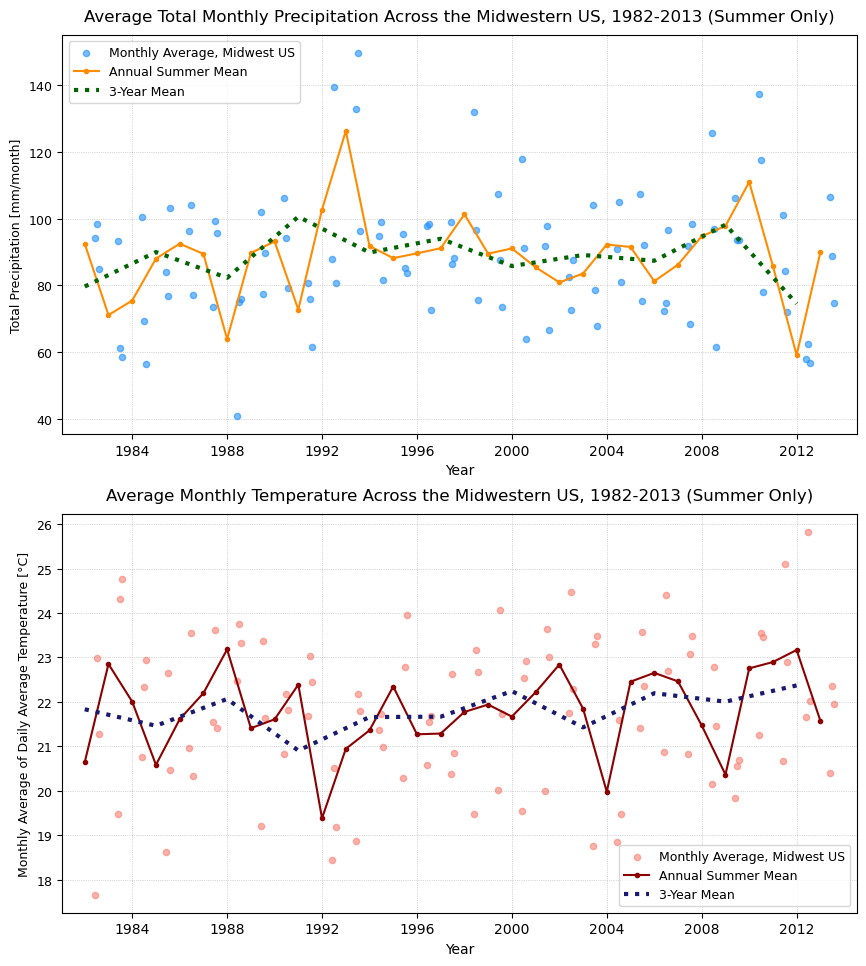

In [7]:
## Line plots: Visualization
fig, axes = plt.subplots(nrows=2, figsize=(10.25, 11.4))
fig.subplots_adjust(hspace=0.2) 
ax0, ax1 = axes

## PRECIPITATION PLOT
## Weighted average total millimeters of rain per month across the Midwestern US during the summer months 1982-2013

ax0.scatter(prcp_weighted_avg['time'], prcp_weighted_avg, 
            label='Monthly Average, Midwest US', alpha=0.6, s=20, color='dodgerblue')
ax0.plot(prcp_weighted_annual_avg['time'], prcp_weighted_annual_avg, 
         label='Annual Summer Mean', linestyle='-', marker='.', color='darkorange')
ax0.plot(prcp_weighted_3yr_avg['time'], prcp_weighted_3yr_avg,
         label='3-Year Mean',linestyle=':', linewidth=3, color='darkgreen')

ax0.legend(prop={'size': 9})
ax0.margins(x=0.03)
ax0.set_ylabel('Total Precipitation [mm/month]', fontsize=9)
ax0.set_xlabel('Year', fontsize=10)
ax0.grid(True, which='both', linewidth=0.5, color='grey', linestyle=':', alpha=0.6)
ax0.tick_params(axis='y', which='major', labelsize=9)
ax0.set_title("Average Total Monthly Precipitation Across the Midwestern US, 1982-2013 (Summer Only)", 
              fontsize=12, pad=10)


## TEMPERATURE PLOT
## Weighted midwestern monthly average of daily average temperatures in degrees celsius, 
## across the the Midwestern US during the summer months 1982-2013
ax1.scatter(temp_weighted_avg['time'], temp_weighted_avg, 
            label='Monthly Average, Midwest US', alpha=0.6, s=20, color='salmon')
ax1.plot(temp_weighted_annual_avg['time'], temp_weighted_annual_avg, 
         label='Annual Summer Mean', linestyle='-', marker='.', color='darkred')
ax1.plot(temp_weighted_3yr_avg['time'], temp_weighted_3yr_avg,
         label='3-Year Mean',linestyle=':', linewidth=3, color='midnightblue')

ax1.legend(prop={'size': 9})
ax1.margins(x=0.03)
ax1.set_ylabel('Monthly Average of Daily Average Temperature [°C]', fontsize=9)
ax1.set_xlabel('Year', fontsize=10)
ax1.grid(True, which='both', linewidth=0.5, color='grey', linestyle=':', alpha=0.6)
ax1.tick_params(axis='y', which='major', labelsize=9)
ax1.set_title("Average Monthly Temperature Across the Midwestern US, 1982-2013 (Summer Only)", fontsize=12, pad=10)

plt.show()

# Results: Individual Trend Maps

Notably for all of these maps, these are not strict comparisons between 2013 and 1982, they instead show the overall trend for each coordinate over the course of the entire dataset. This is to capture the overall change in an area and have it less likely that a single year might misrepresent a longer pattern in the data.

The individual trend maps for temperature and precipitation expand on and give more insight into the patterns explored in the timeseries analysis. The precipitation plot in particular shows that while the region can be averaged into a figure that indicates a lack of notable change in weather, looking more regionally shows that in some areas farmers are receiving an additional 45 mm of rain each month every summer, while others nearby may be dealing with similarly drier summers when compared to recent decades. Generally, eastern areas of the midwest appear to be trending wetter in these months, and the western areas more dry, but with an overall spatial heterogeneity in the direction and intensity of these changes in precipitation.

In contrast, aligning with what was shown in the temperature timeseries, the trend map for temperature shows a general trend of warming throughout the midwestern states. While in the central region there are areas of very moderate cooling trends, other areas, such as the southwestern corner of the map, in addition to areas in the state of Michigan, show summer monthly average temperature increases of roughly two degrees celsius over the time of the dataset. 

Spatially, the FAPAR trend map shows the western portion of the midwest as having large areas of both subtle increases and decreases in the percent of photosynthetically active radition being absorbed by plants. While the trend seems to be moreso increasing FAPAR in the western area of this region, the eastern portion of these states show much less, if any, trending change, with several small pockets of notable decreases in lower Minnesota, upper Iowa, and Michigan's Upper Peninsula. These FAPAR trends are also consistent with those seen in the LAI trend map, with more change occuring overall in the western portion of the region and the trending in general showing an increase in LAI over the course of the dataset, but with the same areas as exceptions, with decreasing values, as was seen in the FAPAR trend map. In both of these maps, large areas show little to no trending change.

In [8]:
## Create trend information for precipitation map

prcp_data = prcp_summer_ds.prcp
nt, nlat, nlon = prcp_data.shape  
ngrd = nlat * nlon  

prcp_grd = prcp_data.values.reshape((nt, ngrd))  
x = np.linspace(1, nt, nt) 

prcp_trend = np.empty((ngrd, 1))
prcp_trend[:, :] = np.nan
 

for i in range(ngrd):
    y = prcp_grd[:, i]  
    if not np.isnan(y[0]): 
        z = np.polyfit(x, y, 1)  
## Trend is meant to encompass the total time period: 96 steps (3 months a year from 1982-2013)
        prcp_trend[i, 0] = z[0] * 96.0

prcp_trend_map = prcp_trend.reshape((nlat, nlon))

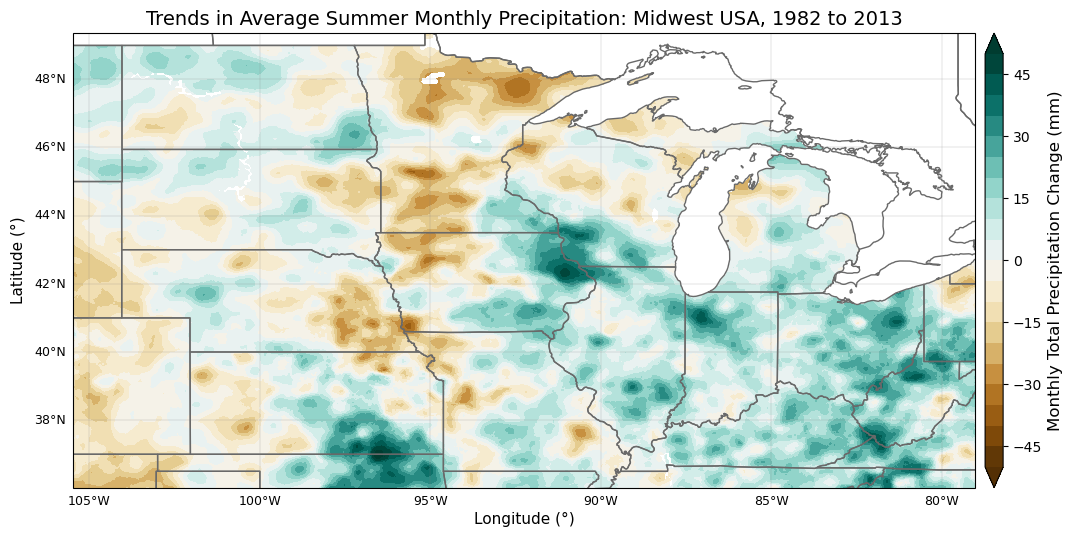

In [27]:
## Mapping precipitation trend

lats = prcp_summer_ds['lat'].values
lons = prcp_summer_ds['lon'].values 

fig, ax = plt.subplots(figsize=(12, 9),
    subplot_kw={"projection": ccrs.PlateCarree()},)

clevs = np.linspace(-50, 50, 21)  
cs = ax.contourf(
    lons,
    lats,
    prcp_trend_map,
    clevs,
    cmap= 'BrBG',
    extend="both",)

ax.set_title("Trends in Average Summer Monthly Precipitation: Midwest USA, 1982 to 2013", fontsize=14)

ax.add_feature(cfeature.STATES, linestyle='-', edgecolor='dimgray') 

## Axis information
gl = ax.gridlines(draw_labels=True, linestyle="-", linewidth=0.3, alpha=0.5, color='gray')
gl.right_labels = False  
gl.top_labels = False    
gl.xlabel_style = {"fontsize": 9}
gl.ylabel_style = {"fontsize": 9}

ax.text(-0.07, 0.5, "Latitude (°)", transform=ax.transAxes, rotation="vertical", 
        va="center", fontsize=11)
ax.text(0.5, -0.08, "Longitude (°)", transform=ax.transAxes, 
        ha="center", fontsize=11)

## Colorbar information
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="2%", pad=0.1, axes_class=plt.Axes)
cbar = plt.colorbar(cs, cax=cax, orientation="vertical")
cbar.set_label("Monthly Total Precipitation Change (mm)", fontsize=12)

plt.show()

In [9]:
## Create trend information for temperature map

tavg_data = temp_summer_ds.tavg
nt, nlat, nlon = tavg_data.shape  
ngrd = nlat * nlon  

tavg_grd = tavg_data.values.reshape((nt, ngrd))  
x = np.linspace(1, nt, nt)   

tavg_trend = np.empty((ngrd, 1))
tavg_trend[:, :] = np.nan

for i in range(ngrd):
    y = tavg_grd[:, i]  
    if not np.isnan(y[0]):  
        z = np.polyfit(x, y, 1)  
        tavg_trend[i, 0] = z[0] * 96.0

tavg_trend_map = tavg_trend.reshape((nlat, nlon))

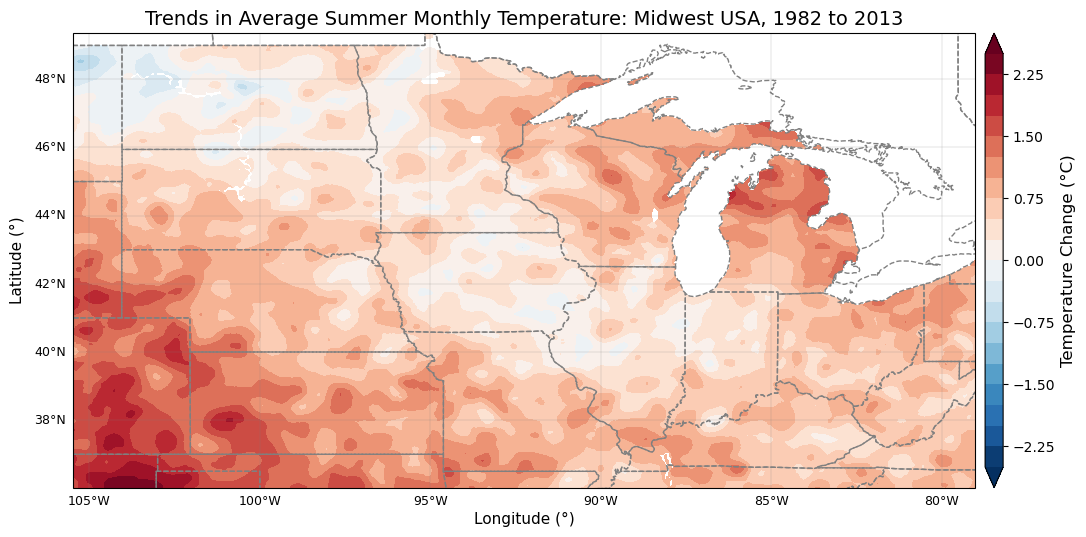

In [31]:
## Mapping precipitation trend

lats = temp_summer_ds['lat'].values
lons = temp_summer_ds['lon'].values 

fig, ax = plt.subplots(figsize=(12, 9),
    subplot_kw={"projection": ccrs.PlateCarree()},)

clevs = np.linspace(-2.5, 2.5, 21) 
cs = ax.contourf(
    lons,
    lats,
    tavg_trend_map,  
    clevs,
    cmap=plt.cm.RdBu_r,
    extend="both",)

ax.set_title("Trends in Average Summer Monthly Temperature: Midwest USA, 1982 to 2013", fontsize=14)

## Axis information
ax.add_feature(cfeature.STATES, linestyle='--', edgecolor='gray')  
gl = ax.gridlines(draw_labels=True, linestyle="-", linewidth=0.3, alpha=0.5, color='gray')
gl.right_labels = False  
gl.top_labels = False    
gl.xlabel_style = {"fontsize": 9}
gl.ylabel_style = {"fontsize": 9}

ax.text(-0.07, 0.5, "Latitude (°)", transform=ax.transAxes, rotation="vertical", 
        va="center", fontsize=11)
ax.text(0.5, -0.08, "Longitude (°)", transform=ax.transAxes, 
        ha="center", fontsize=11)

## Colorbar information
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="2%", pad=0.1, axes_class=plt.Axes)
cbar = plt.colorbar(cs, cax=cax, orientation="vertical")
cbar.set_label("Temperature Change (°C)", fontsize=12)

plt.show()

In [10]:
## Create trend information for FAPAR map

fapar_data = green_final_ds.FAPAR
nt, nlat, nlon = fapar_data.shape  
ngrd = nlat * nlon 

fapar_grd = fapar_data.values.reshape((nt, ngrd))  
x = np.linspace(1, nt, nt) 

fapar_trend = np.empty((ngrd, 1)) 
fapar_trend[:, :] = np.nan

for i in range(ngrd):
    y = fapar_grd[:, i]  
    if not np.isnan(y[0]):   
        z = np.polyfit(x, y, 1)  
        fapar_trend[i, 0] = z[0] * 96.0  

fapar_trend_map = fapar_trend.reshape((nlat, nlon))

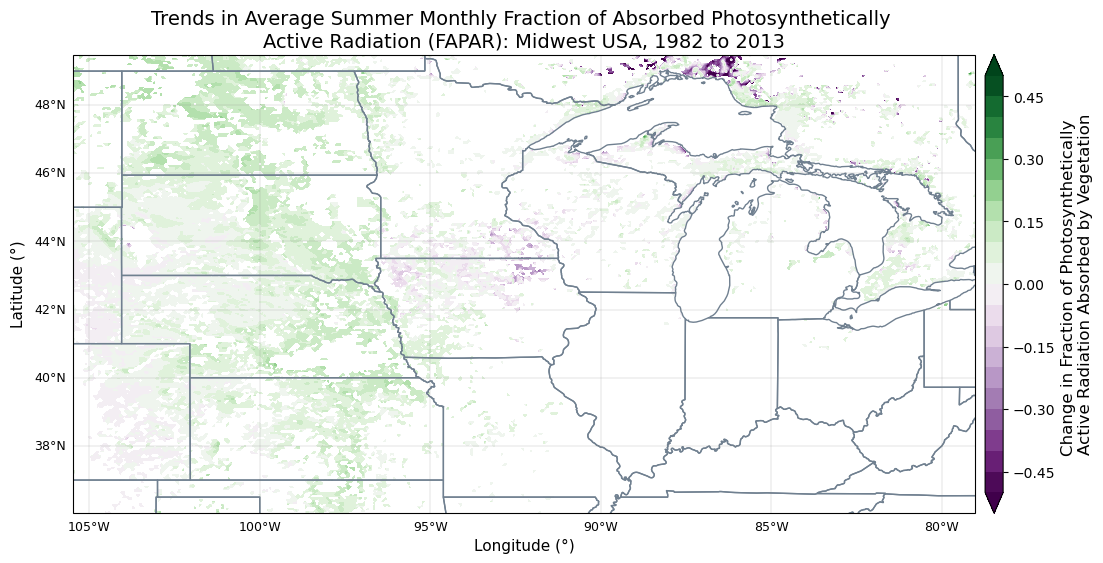

In [16]:
## Mapping FAPAR trend

lats = green_final_ds['latitude'].values
lons = green_final_ds['longitude'].values 

fig, ax = plt.subplots(figsize=(12, 9),
    subplot_kw={"projection": ccrs.PlateCarree()},)

clevs = np.linspace(-.5, .5, 21)  
cs = ax.contourf(
    lons,
    lats,
    fapar_trend_map,
    clevs,
    cmap='PRGn',
    extend="both",)

ax.set_title(
    "Trends in Average Summer Monthly Fraction of Absorbed Photosynthetically \nActive Radiation (FAPAR): Midwest USA, 1982 to 2013",fontsize=14)

ax.coastlines()
ax.add_feature(cfeature.STATES, linestyle='-', edgecolor='slategray')
 
gl = ax.gridlines(draw_labels=True, linestyle="-", linewidth=0.3, alpha=0.5, color='gray')
gl.right_labels = False  
gl.top_labels = False    
gl.xlabel_style = {"fontsize": 9}
gl.ylabel_style = {"fontsize": 9}

ax.text(-0.07, 0.5, "Latitude (°)", transform=ax.transAxes, rotation="vertical", 
        va="center", fontsize=11)
ax.text(0.5, -0.08, "Longitude (°)", transform=ax.transAxes, 
        ha="center", fontsize=11)

divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="2%", pad=0.1, axes_class=plt.Axes)
cbar = plt.colorbar(cs, cax=cax, orientation="vertical")
cbar.set_label("Change in Fraction of Photosynthetically \nActive Radiation Absorbed by Vegetation", fontsize=12)

plt.show()

In [21]:
## Create trend information for LAI map

LAI_data = green_final_ds.LAI
nt, nlat, nlon = LAI_data.shape  
ngrd = nlat * nlon  

LAI_grd = LAI_data.values.reshape((nt, ngrd))  
x = np.linspace(1, nt, nt) 

LAI_trend = np.empty((ngrd, 1))
LAI_trend[:, :] = np.nan

for i in range(ngrd):
    y = LAI_grd[:, i]  
    if not np.isnan(y[0]):   
        z = np.polyfit(x, y, 1)  
        LAI_trend[i, 0] = z[0] * 96.0  

LAI_trend_map = LAI_trend.reshape((nlat, nlon))

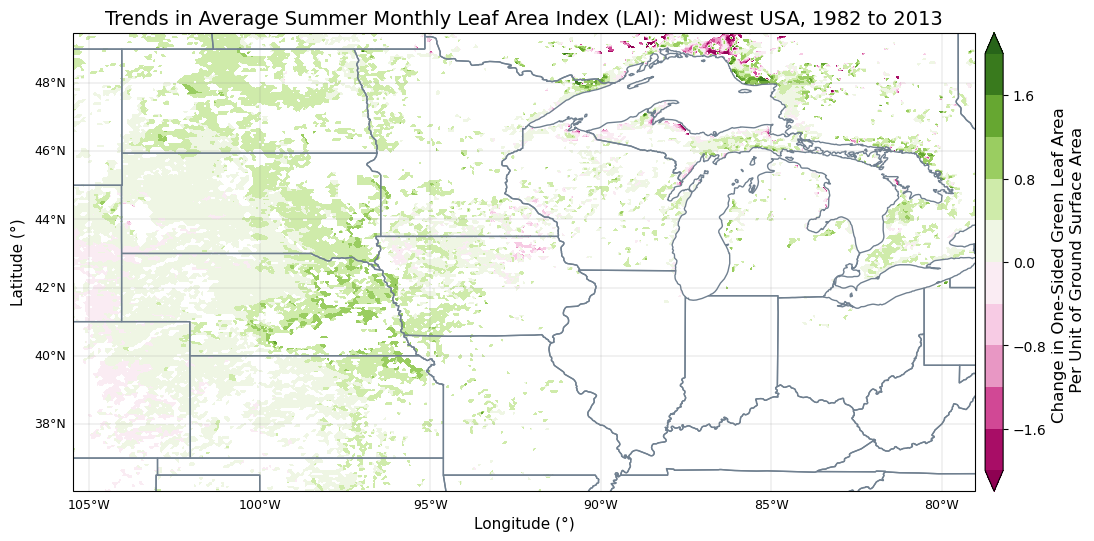

In [25]:
## Mapping FAPAR trend

lats = green_final_ds['latitude'].values
lons = green_final_ds['longitude'].values 

fig, ax = plt.subplots(figsize=(12, 9),
    subplot_kw={"projection": ccrs.PlateCarree()},)

clevs = np.linspace(-2, 2, 11) 
cs = ax.contourf(
    lons,
    lats,
    LAI_trend_map,
    clevs,
    cmap='PiYG',
    extend="both",)

ax.set_title("Trends in Average Summer Monthly Leaf Area Index (LAI): Midwest USA, 1982 to 2013", fontsize=14)

ax.coastlines()
ax.add_feature(cfeature.STATES, linestyle='-', edgecolor='slategray') 
gl = ax.gridlines(draw_labels=True, linestyle="-", linewidth=0.3, alpha=0.5, color='gray')
gl.right_labels = False  
gl.top_labels = False    
gl.xlabel_style = {"fontsize": 9}
gl.ylabel_style = {"fontsize": 9}

ax.text(-0.07, 0.5, "Latitude (°)", transform=ax.transAxes, rotation="vertical", 
        va="center", fontsize=11)
ax.text(0.5, -0.08, "Longitude (°)", transform=ax.transAxes, 
        ha="center", fontsize=11)

divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="2%", pad=0.1, axes_class=plt.Axes)
cbar = plt.colorbar(cs, cax=cax, orientation="vertical")
cbar.set_label("Change in One-Sided Green Leaf Area \n Per Unit of Ground Surface Area", fontsize=12)

plt.show()

# Results: Comparison Trend Maps

The comparison trend maps show an overlay of precipitation and temperature trends with plant health indicator trends, either FAPAR or LAI. With both of the plant health indicators, as seen in seperate maps, there does not appear to be a spatial relationship demonstrated between areas of greater change in precipitation and temperature and a decrease in the plant health indicators. As any "extreme" variation in precipitation or temperature can lead to plant stress, with too much or too little both being harmful, this map uses colormapping that has more pronounced changes to trends in precipitation and temperature shaded in darker colors, regardless of the directionality of the trend. Therefore, if areas of negative plant health trends overlapped more consistently with these darker regions, it could imply a relationship between changing precipitation and temperature trends and negative plant health indicators. However, while some areas of plant decline are in darker areas of the map, such as northern Michigan, other pockets of negatively trending plant health are areas of the map with less pronounced changes in regional precipitation and temperature trends (e.g. southern Minnesota/northern Iowa).

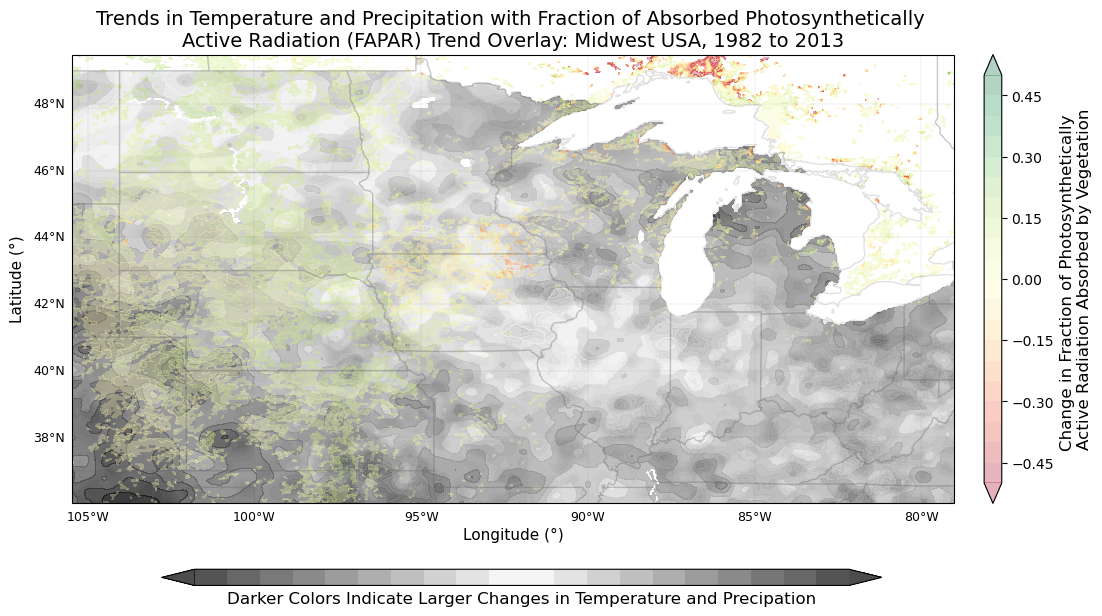

In [18]:
## Creating overlap map for FAPAR trend compared to intensity of precipitation and temperature changes

colors = [
    (0, 0, 0),  
    (1, 1, 1),       
    (0, 0, 0)   ]
cmap = mcolors.LinearSegmentedColormap.from_list("CustomGray", colors)

## Set up the base map
fig, ax = plt.subplots(figsize=(12, 9), subplot_kw={"projection": ccrs.PlateCarree()})

## Precipitation trends
lats_prcp = prcp_summer_ds['lat'].values
lons_prcp = prcp_summer_ds['lon'].values
clevs_prcp = np.linspace(-50, 50, 21)
cs_prcp = ax.contourf(lons_prcp, lats_prcp, prcp_trend_map, clevs_prcp, cmap=cmap, extend="both", alpha=0.7)

## Temperature trends
lats_temp = temp_summer_ds['lat'].values
lons_temp = temp_summer_ds['lon'].values
clevs_temp = np.linspace(-2.5, 2.5, 21)
cs_temp = ax.contourf(lons_temp, lats_temp, tavg_trend_map, clevs_temp, cmap=cmap, extend="both", alpha=0.7)

## FAPAR trends
lats_fapar = green_final_ds['latitude'].values
lons_fapar = green_final_ds['longitude'].values
clevs_fapar = np.linspace(-0.5, 0.5, 21)
cs_fapar = ax.contourf(lons_fapar, lats_fapar, fapar_trend_map, clevs_fapar, cmap='RdYlGn', extend="both", alpha=.3)

## Map Features
ax.coastlines()
ax.add_feature(cfeature.STATES, linestyle='-', edgecolor='dimgray', alpha=0.2)

## FAPAR Colorbar
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="2%", pad=0.3, axes_class=plt.Axes)
cbar = plt.colorbar(cs_fapar, cax=cax, orientation="vertical")
cbar.set_label("Change in Fraction of Photosynthetically \nActive Radiation Absorbed by Vegetation", fontsize=12)

## Temp and Precip colorbar
fig.subplots_adjust(bottom=0.001)  
cax2 = fig.add_axes([0.2, 0.1, 0.6, 0.018]) 
cbar2 = plt.colorbar(cs_prcp, cax=cax2, orientation="horizontal")
cbar2.set_label("Darker Colors Indicate Larger Changes in Temperature and Precipation", fontsize=12)
cbar2.ax.xaxis.set_ticks([])  
cbar2.ax.xaxis.set_ticklabels([])

## Lat and Lon Grids
gl = ax.gridlines(draw_labels=True, linestyle="-", linewidth=0.3, alpha=0.3, color='gray')
gl.right_labels = False  
gl.top_labels = False    
gl.xlabel_style = {"fontsize": 9}
gl.ylabel_style = {"fontsize": 9}

ax.text(-0.07, 0.5, "Latitude (°)", transform=ax.transAxes, rotation="vertical", 
        va="center", fontsize=11)
ax.text(0.5, -0.08, "Longitude (°)", transform=ax.transAxes, 
        ha="center", fontsize=11)

## Title
ax.set_title(
    "Trends in Temperature and Precipitation with Fraction of Absorbed Photosynthetically \nActive Radiation (FAPAR) Trend Overlay: Midwest USA, 1982 to 2013"
    ,fontsize=14)

plt.show()

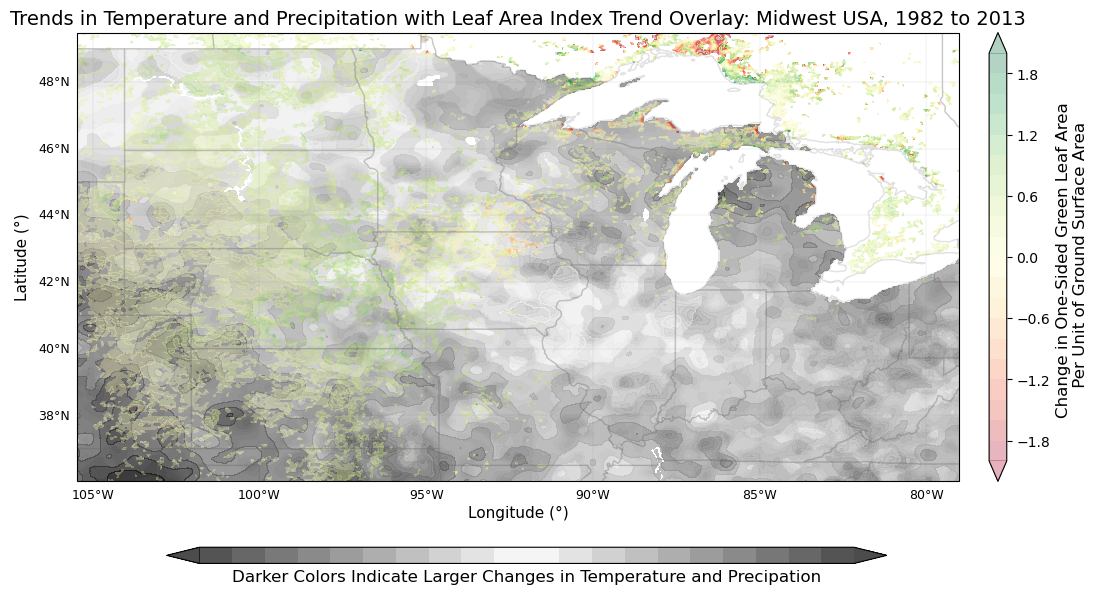

In [26]:
## Creating overlap map for LAI trend compared to intensity of precipitation and temperature changes

colors = [
    (0, 0, 0),  
    (1, 1, 1),       
    (0, 0, 0)   ]
cmap = mcolors.LinearSegmentedColormap.from_list("CustomGray", colors)

## Basemap
fig, ax = plt.subplots(figsize=(12, 9), subplot_kw={"projection": ccrs.PlateCarree()})

## Precip overlay
lats_prcp = prcp_summer_ds['lat'].values
lons_prcp = prcp_summer_ds['lon'].values
clevs_prcp = np.linspace(-50, 50, 21)
cs_prcp = ax.contourf(lons_prcp, lats_prcp, prcp_trend_map, clevs_prcp, cmap=cmap, extend="both", alpha=0.7)

## Temp overlay
lats_temp = temp_summer_ds['lat'].values
lons_temp = temp_summer_ds['lon'].values
clevs_temp = np.linspace(-2.5, 2.5, 21)
cs_temp = ax.contourf(lons_temp, lats_temp, tavg_trend_map, clevs_temp, cmap=cmap, extend="both", alpha=0.7)

## LAI overlay
lats_lai = green_final_ds['latitude'].values
lons_lai = green_final_ds['longitude'].values
clevs_lai = np.linspace(-2, 2, 21) 
cs_LAI = ax.contourf(lons_lai, lats_lai, LAI_trend_map, clevs_lai, cmap='RdYlGn', extend="both", alpha=.3)

## LAI colorbar
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="2%", pad=0.3, axes_class=plt.Axes)
cbar = plt.colorbar(cs_LAI, cax=cax, orientation="vertical")
cbar.set_label("Change in One-Sided Green Leaf Area \n Per Unit of Ground Surface Area", fontsize=12)

## Temp and precip colorbar
fig.subplots_adjust(bottom=0.001)  
cax2 = fig.add_axes([0.2, 0.1, 0.6, 0.018]) 
cbar2 = plt.colorbar(cs_prcp, cax=cax2, orientation="horizontal")
cbar2.set_label("Darker Colors Indicate Larger Changes in Temperature and Precipation", fontsize=12)
cbar2.ax.xaxis.set_ticks([])  
cbar2.ax.xaxis.set_ticklabels([])

## Map features
ax.coastlines()
ax.add_feature(cfeature.STATES, linestyle='-', edgecolor='dimgray', alpha=0.2)

gl = ax.gridlines(draw_labels=True, linestyle="-", linewidth=0.3, alpha=0.3, color='gray')
gl.right_labels = False  
gl.top_labels = False    
gl.xlabel_style = {"fontsize": 9}
gl.ylabel_style = {"fontsize": 9}

ax.text(-0.07, 0.5, "Latitude (°)", transform=ax.transAxes, rotation="vertical", 
        va="center", fontsize=11)
ax.text(0.5, -0.08, "Longitude (°)", transform=ax.transAxes, 
        ha="center", fontsize=11)

ax.set_title("Trends in Temperature and Precipitation with Leaf Area Index Trend Overlay: Midwest USA, 1982 to 2013", fontsize=14)

plt.show()

# Discussion

While my findings did not demonstrate any clear relationships between changing trends in precipitation and temperature and plant health indicators, this does not mean that these relationships do not exist. These figures and maps do show that change over time is occuring throughout this area, already creating summer weather conditions that impact the nature of what farmers can grow and what they must increasingly prepare for during peak growing season. While LAI and FAPAR in general may not show widespread trends of failing plant health across the midwest during summer months, it may be that these indicators are not ideal for capturing field crop data, and a different indicator may have shown a more spatially pronounced relationships with these variables.

Generally, in addition to considering other plant health indicators, I believe that this analysis could be both expanded on and refined in meaningful ways. Firstly, with more memory and processing power, it would be possible to look at daily data for many of these variables, which would give more nuance to the analysis with a higher resolution dataset to work with. Furthermore, being able to limit the data with a more detailed spatial range, including truly only the midwestern states, could provide insight more focused on just this agriculturally important region. For example, currently the entire state of Kentucky, which is not traditionally included in the midwest, is included in this dataset. The precipitation trend for Kentucky was overwhelmingly positive, meaning the general midwestern average for precipitation may in reality be trending more dry than my time series would suggest. The timeseries for precipitation and temperature in the midwest could be expanded on both in terms of including daily data, but also looking at longer trends and changes over time, as these data go back much farther than the FAPAR/LAI data. While there may be less of an ability to directly compare the trends between the datasets, this could help to make clear any trends that are present but more subtle in the current timeseries.

Furthermore, this analysis assumed a close spatial and temporal relationship between weather trends and plant health indicators, whereas there may be delays or expanded zones of influence from weather impacts that are not reflected in this analysis, which could be addresse

Overall, while I was able to visualize and explore some the the overall trends in my variables of interest for this region and their temporal and spatial qualities, I was not able to clearly demonstrate a relationship between these my planet health indicators and the temperature or precipitation variables in question. However, I believe that there are many ways in which these data and others could be further explored in future analysis. 
